# NBA Shooting & Performance Projections

In [1]:
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Data and exploratory checks

Everything downstream is built on five real NBA seasons (2021-22 through 2025-26),
pulled from `nba_api`'s league dashboard endpoints and deduplicated to one row per
player-season. Before fitting anything, the checks below validate the assumptions
the models lean on: distribution shape, the age curve, collinearity between shooting
stats, season-to-season persistence, and how much of the variance in shooting is
"which player is this" versus noise.

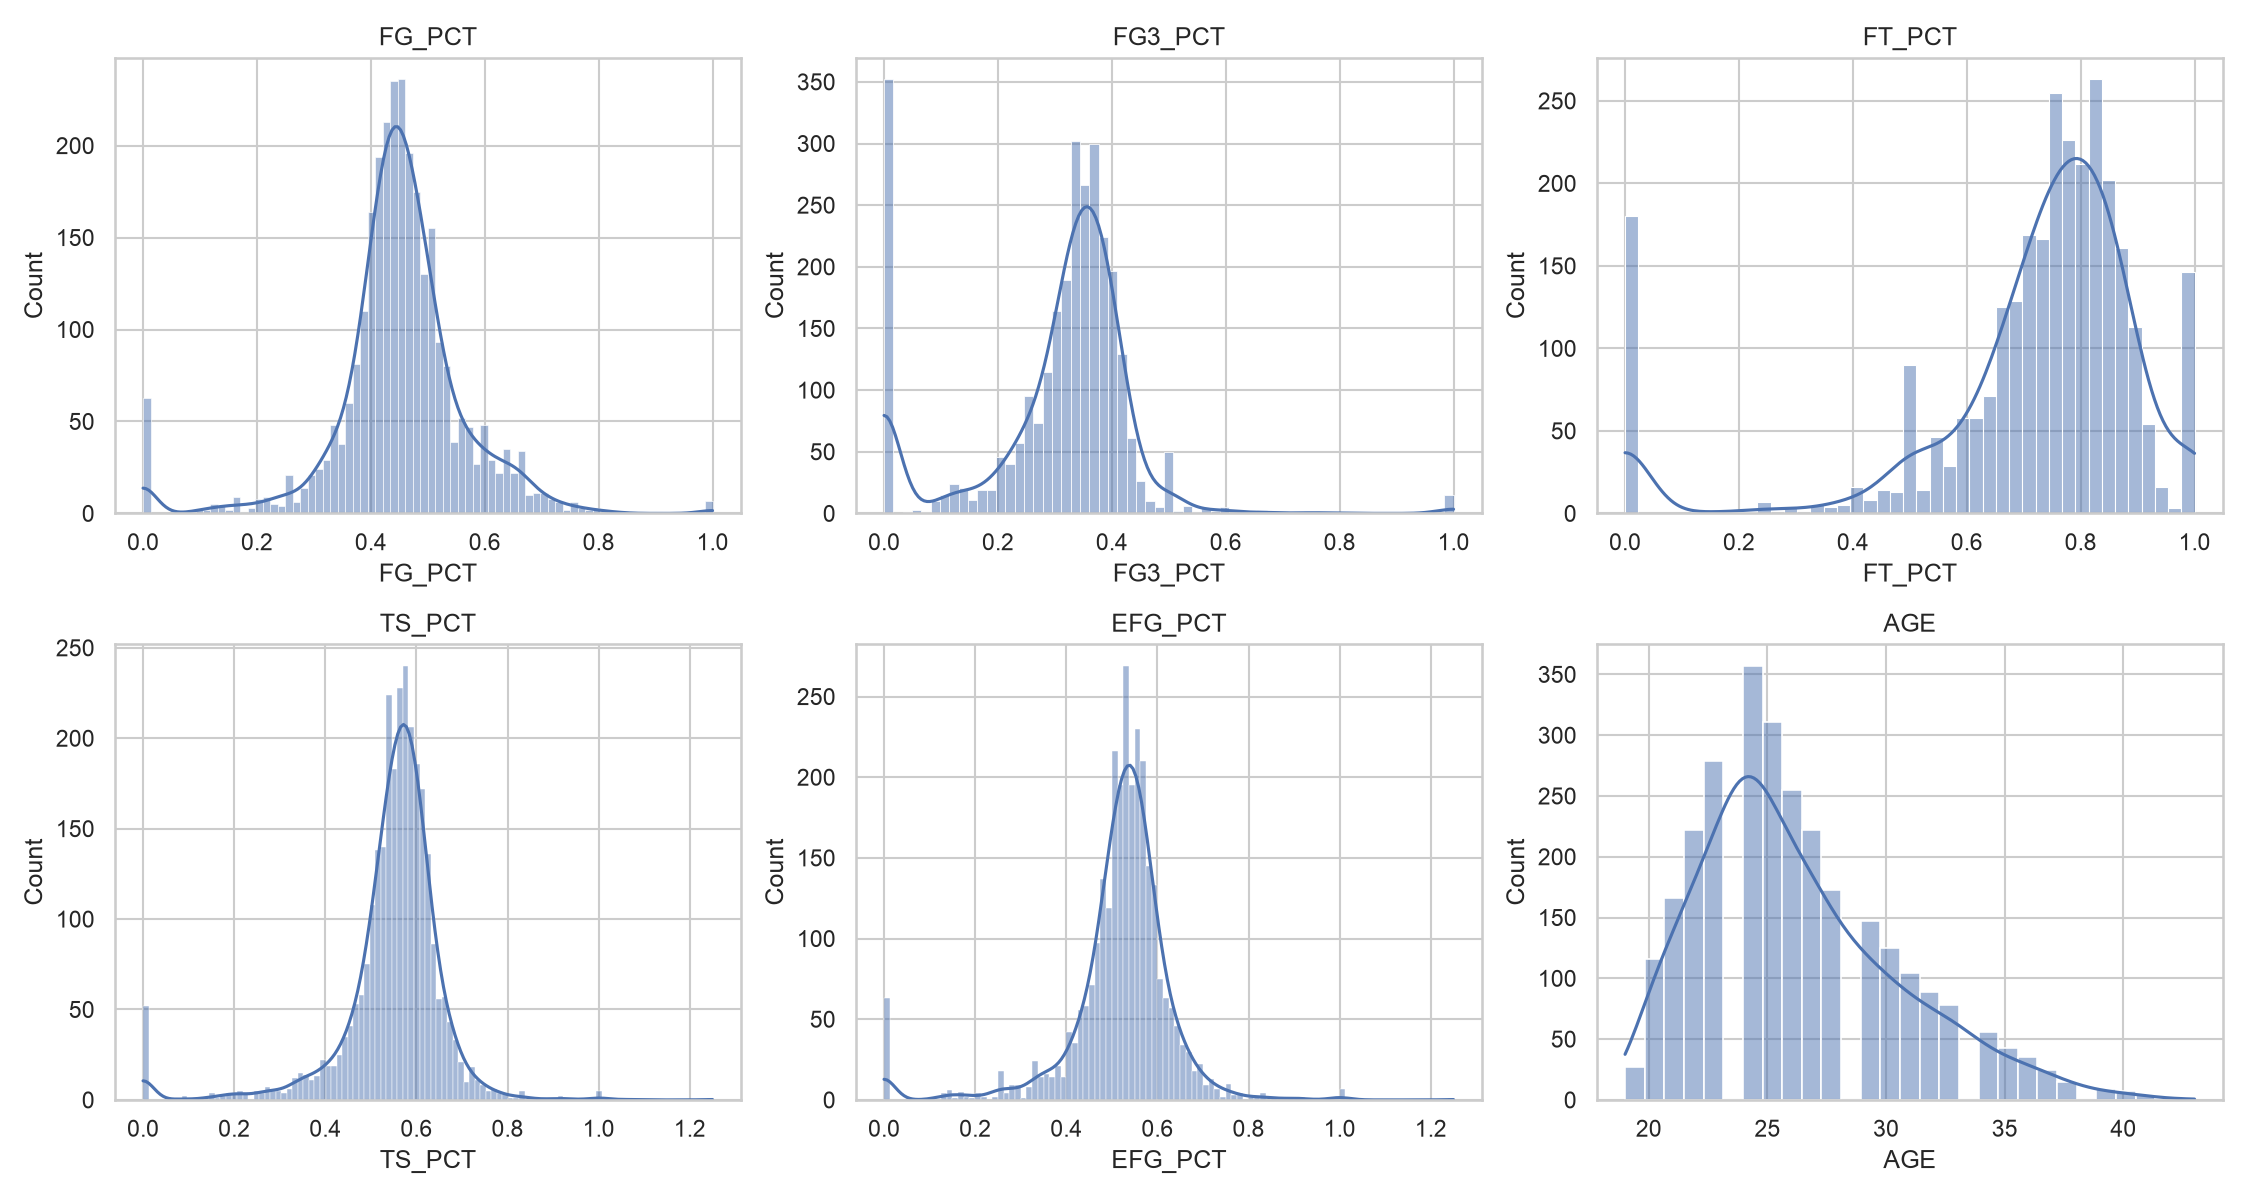

In [2]:
display(Image(filename="eda_output/distributions.png", width=460))

**Distributions.** FG%, FG3%, FT%, TS%, and eFG% are all roughly bell-shaped once
bounded between 0 and 1 (league-mean TS% ≈ 0.55), which is good news for a Gaussian
likelihood and the direct justification for the pooled model's intercept prior in §2
(`alpha ~ Normal(y.mean(), 0.2)`, anchored to this data mean rather than an arbitrary
constant). The tails come almost entirely from very-low-attempt players (someone who
goes 2-for-3 for a season can show a "67%"), which is why every model downstream
applies a minimum-attempts/minutes floor before fitting.

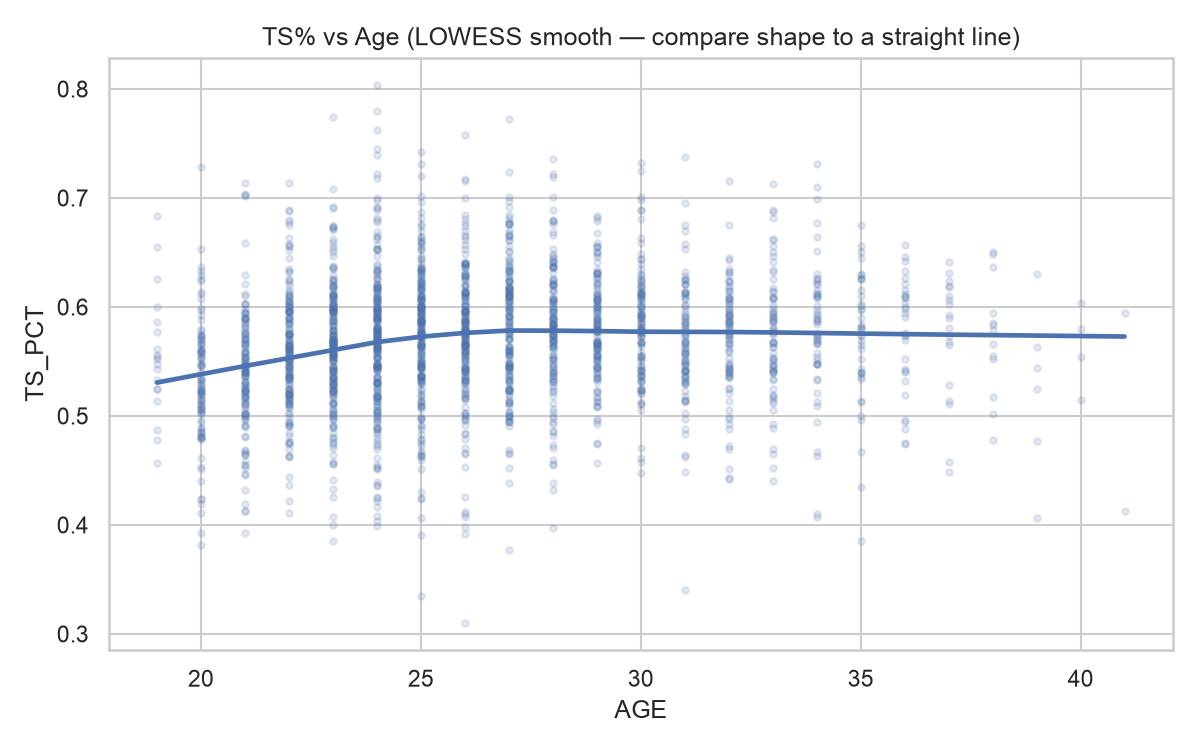

In [3]:
display(Image(filename="eda_output/ts_pct_vs_age.png", width=460))

**Age curve.** The LOWESS smooth is visibly curved, not a straight line: mean TS%
climbs from 0.536 at 18-20 to a peak of 0.581 around 28-30, then drifts down through
the late 30s, a shape a single linear age term can't represent (it would average a
rising and falling slope into one number). That's the concrete evidence behind
`age + age²` as covariates in every model below.

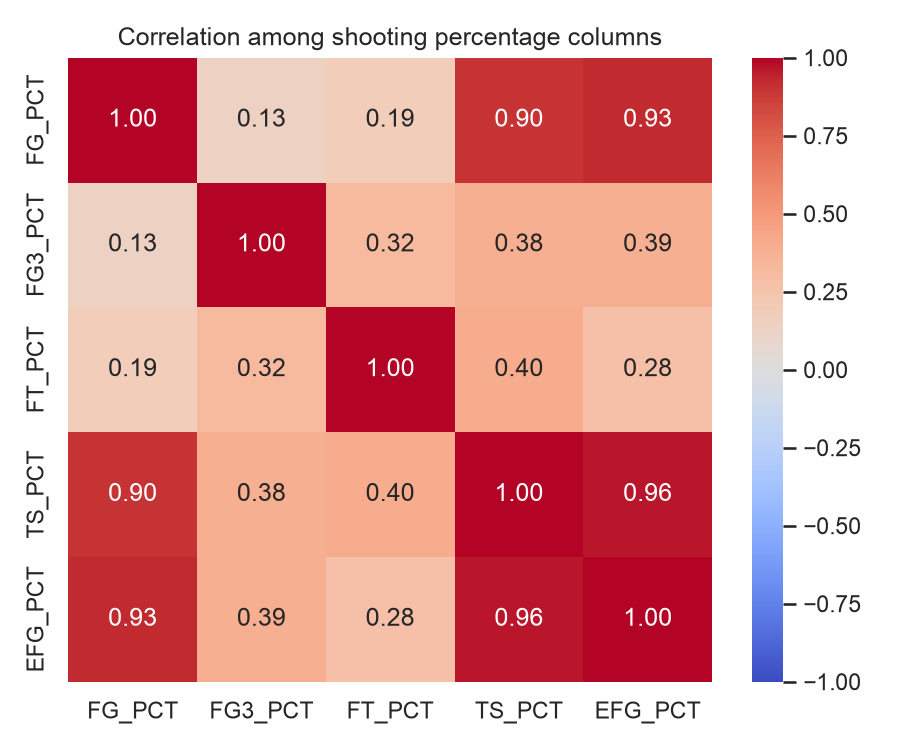

In [4]:
display(Image(filename="eda_output/shooting_corr_heatmap.png", width=460))

**Collinearity.** FG%, FG3%, FT%, and eFG% are all mechanically related to TS% (it's
a weighted function of the others), and variance inflation factors among them run
from ~11 to over 400, far past the usual danger threshold of 5. So the models never
use more than one of them as a predictor: TS% stands on its own as the modeled
quantity, with age, usage, and its own lags as the only predictors, rather than
alongside its own components.

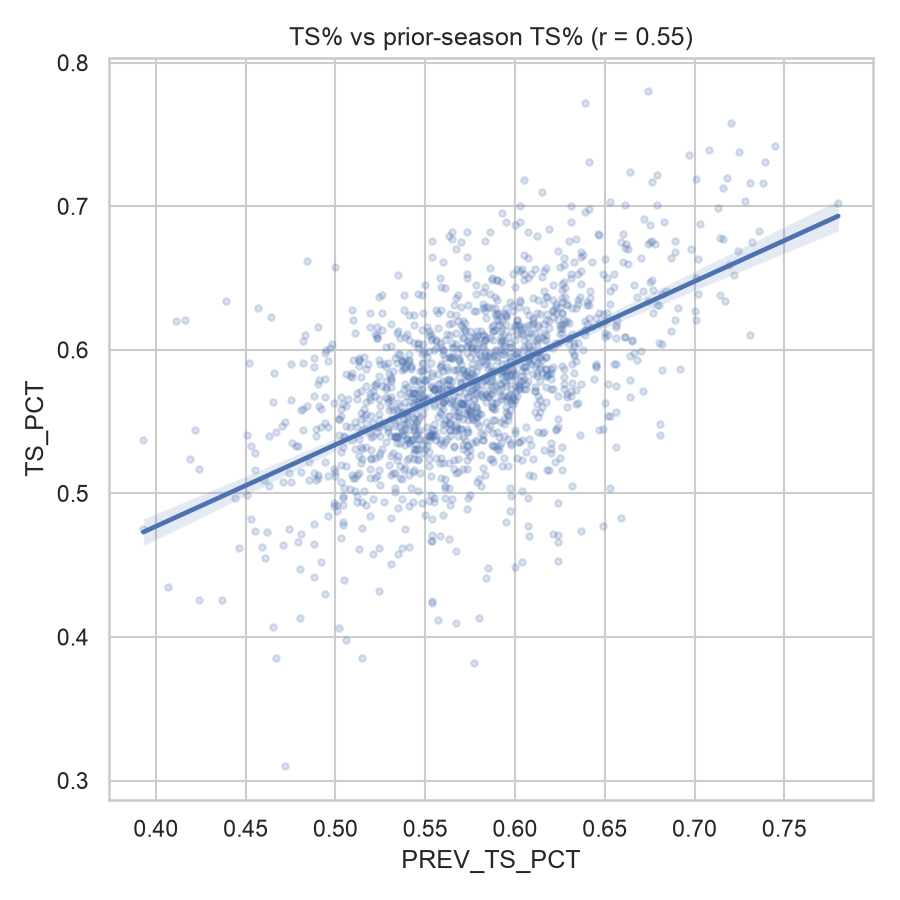

In [5]:
display(Image(filename="eda_output/lag1_ts_pct.png", width=460))

**Season-to-season persistence.** The correlation printed in the chart title is the
core AR(1) check: a player's TS% and their own prior-season TS% are meaningfully
correlated, but with plenty of scatter, which is exactly the case for an
autoregressive structure with real residual uncertainty (not a near-perfect straight
line, and not noise either).

In [6]:
from eda_box_scores import load_data, variance_decomposition_report, sample_size_report

df = load_data("nba_data.csv")
variance_decomposition_report(df)
sample_size_report(df)


=== VARIANCE DECOMPOSITION ===
Between-player variance share: 71.7%
Within-player (season-to-season) variance share: 28.3%
A large between-player share supports a hierarchical model with player-level intercepts rather than pooling everyone together.

=== SAMPLE SIZE / ATTRITION ===
Mean TS% for player-seasons WITH vs WITHOUT a following season (a gap here suggests non-random attrition):
HAS_NEXT_SEASON
False    0.520
True     0.564

62.6% of player-seasons have a usable next season for the AR target.


A ~72% between-player variance share is the direct evidence for the hierarchical
extension in §3 below: most of the spread in TS% is "which player is this," not
season-to-season noise. The attrition check also matters: player-seasons *without* a
following season average noticeably lower TS% than ones with a following season.
Worse shooters leave the sample at a higher rate, a survivorship effect that flexible
lags partly correct for by keeping short-tenured and departing players in the fit
instead of dropping them outright.

## 2. Bayesian Gaussian AR(3) shooting model

The core model projects a player's next TS% from up to three lagged TS% values (each
used only when that exact season actually exists in the data, so a gap year isn't
mistaken for a valid lag), age + age², usage rate, and a covariate for how many lags
are actually available. Missing lags are imputed to the population mean so they
contribute nothing to the prediction, letting a rookie's first qualifying season be
modeled from age and usage alone rather than excluded outright.

Fit with `pm.sample(2000, tune=2000, chains=4, target_accept=0.9)` on 2,286 usable
player-seasons: **0 divergent transitions, max r-hat 1.0008, min ESS (bulk) 6,569**,
a clean fit by every standard MCMC health check.

**Why flexible lags instead of a strict AR(3)?** An earlier version required three
full consecutive prior seasons per player, fitting noticeably better (R² ≈ 0.6) but
on only 540 rows, silently excluding rookies and anyone coming off a gap year. This
version trades some of that fit away (R² = 0.389) for **2,286 rows, a >4x increase
in usable data**, favoring coverage over squeezing out the last bit of accuracy.

**Coefficients** (posterior mean, 94% HDI): every lag's HDI excludes zero, but not in
strictly decaying order: `phi2` (0.006) is smaller than `phi3` (0.013), even though
phi3 reaches two seasons further back, a real, small, non-monotonic pattern, though
the HDIs are close enough that it isn't strong evidence of anything. `beta_usg`'s HDI
straddles zero: once age and shooting history are accounted for, usage rate isn't
pulling separate weight. `beta_n_lags` is small but reliably positive: more career
history behind a projection is associated with slightly higher predicted TS%,
consistent with the survivorship pattern from §1.

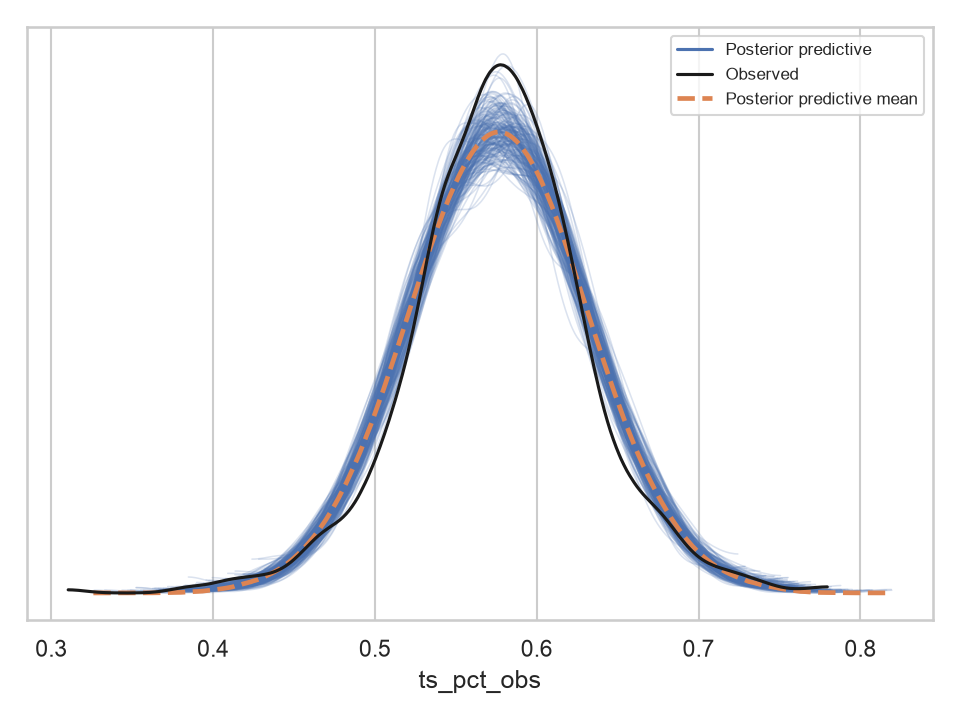

In [7]:
display(Image(filename="bayesian_ar_output/posterior_predictive_check.png", width=460))

**Posterior predictive check.** The observed TS% distribution (dark line) sits
comfortably inside the spread of posterior predictive draws (light lines). Bayesian
R² = 0.389 (± 0.008). The Pareto-k (LOO-CV) diagnostic for this model flags no
observations above the k = 0.7 threshold, unlike the hierarchical extension below.

## 3. Hierarchical extension: player-level intercepts

Adds a partial-pooled, player-specific intercept on top of the same AR(3) + age² +
usage structure, using a non-centered parameterization and `target_accept=0.98`
(raised from the pooled model's 0.9) to handle the sharper posterior geometry created
by players with only 1-2 observations.

**0 divergent transitions, max r-hat 1.0032, min ESS (bulk) 1,599** (`tau_alpha`),
slightly lower effective sample size than the pooled model, but still healthy.
Diagnostics (trace/rank/energy plots) look as clean as the pooled model's above, and
Bayesian R² improves further once player identity is modeled directly.

`phi1`/`phi2`/`phi3` collapse toward (or through) zero here compared to the pooled
model: once 780 free player intercepts are available, they absorb much of what the
AR lags explained in the pooled fit, since the lags are themselves a strong proxy for
"who this player is." The between-player spread (`tau_alpha` ≈ 0.048) is an order of
magnitude larger than an earlier, stricter version of this model produced
(≈0.004-0.011), a direct echo of the ~72% between-player variance share from §1.

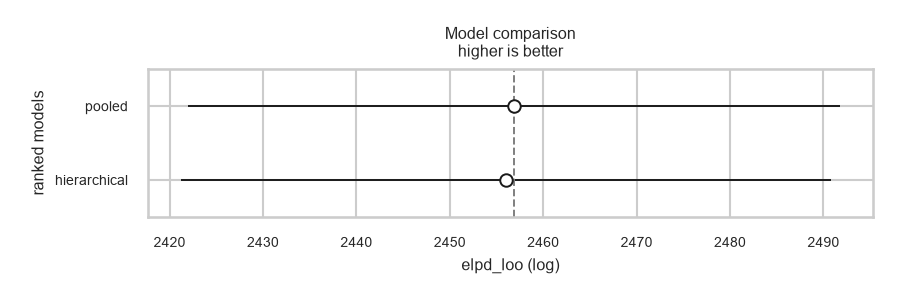

In [8]:
display(Image(filename="bayesian_ar_output/model_comparison.png", width=460))

**Model comparison.** `az.compare` ranks the hierarchical model first by predictive
fit (`elpd_loo`), but its estimate carries a reliability warning: **131 of 2,286
observations (5.7%) have Pareto-k > 0.7** (max 1.13), and 113 of those are a player's
*only* qualifying season in the window. Leaving out someone's one and only data point
removes nearly all information the model has about their intercept, the textbook
failure mode for PSIS-LOO on hierarchical models. **The pooled model's comparison,
not flagged, is the one to trust here**, and it doesn't show the added hierarchical
complexity earning its keep on out-of-sample fit, even though the hierarchical model
is more principled about player-to-player variation. "More sophisticated" and "better
by the numbers" genuinely diverge here, which is worth flagging rather than papering
over.

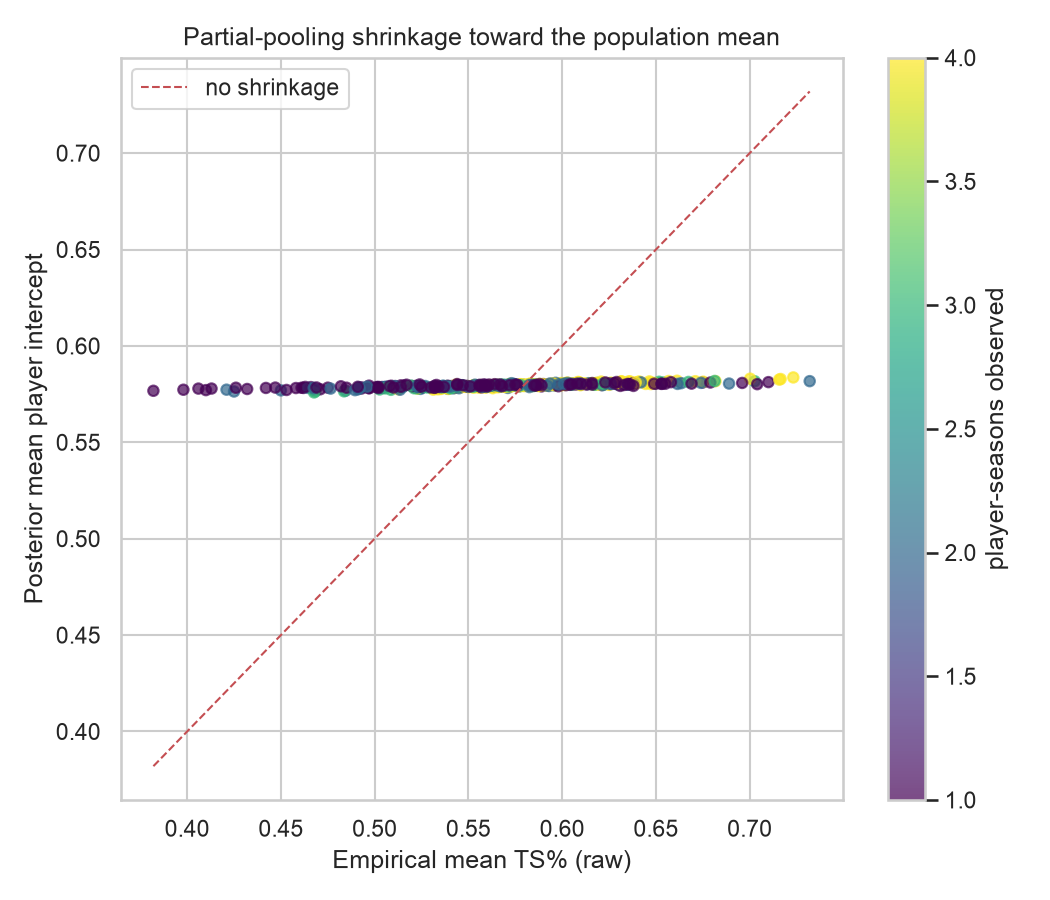

In [9]:
display(Image(filename="bayesian_ar_output/shrinkage_plot.png", width=460))

**Partial-pooling shrinkage.** Each point is one player: empirical mean TS% (x-axis)
against the model's posterior mean intercept (y-axis), colored by observed
player-seasons. Points near the red no-shrinkage line have enough of their own
history that the model trusts their empirical average; points pulled toward the
population mean (concentrated among low-observation-count, darker players) are
partial pooling working as intended: a rookie or injury-shortened season shouldn't
be judged purely on a handful of noisy games.

## 4. Next season's projected top shooters

Using the hierarchical model, every player active in the most recent scraped season
gets a TS% projection for the season after (475 of 780 active players qualify; the
rest have no prior in-window TS% to condition on at all). Usage rate is held at its
most recent observed value: a steady-state assumption about role, not a usage
forecast, so a player about to see a much bigger or smaller role isn't reflected here.

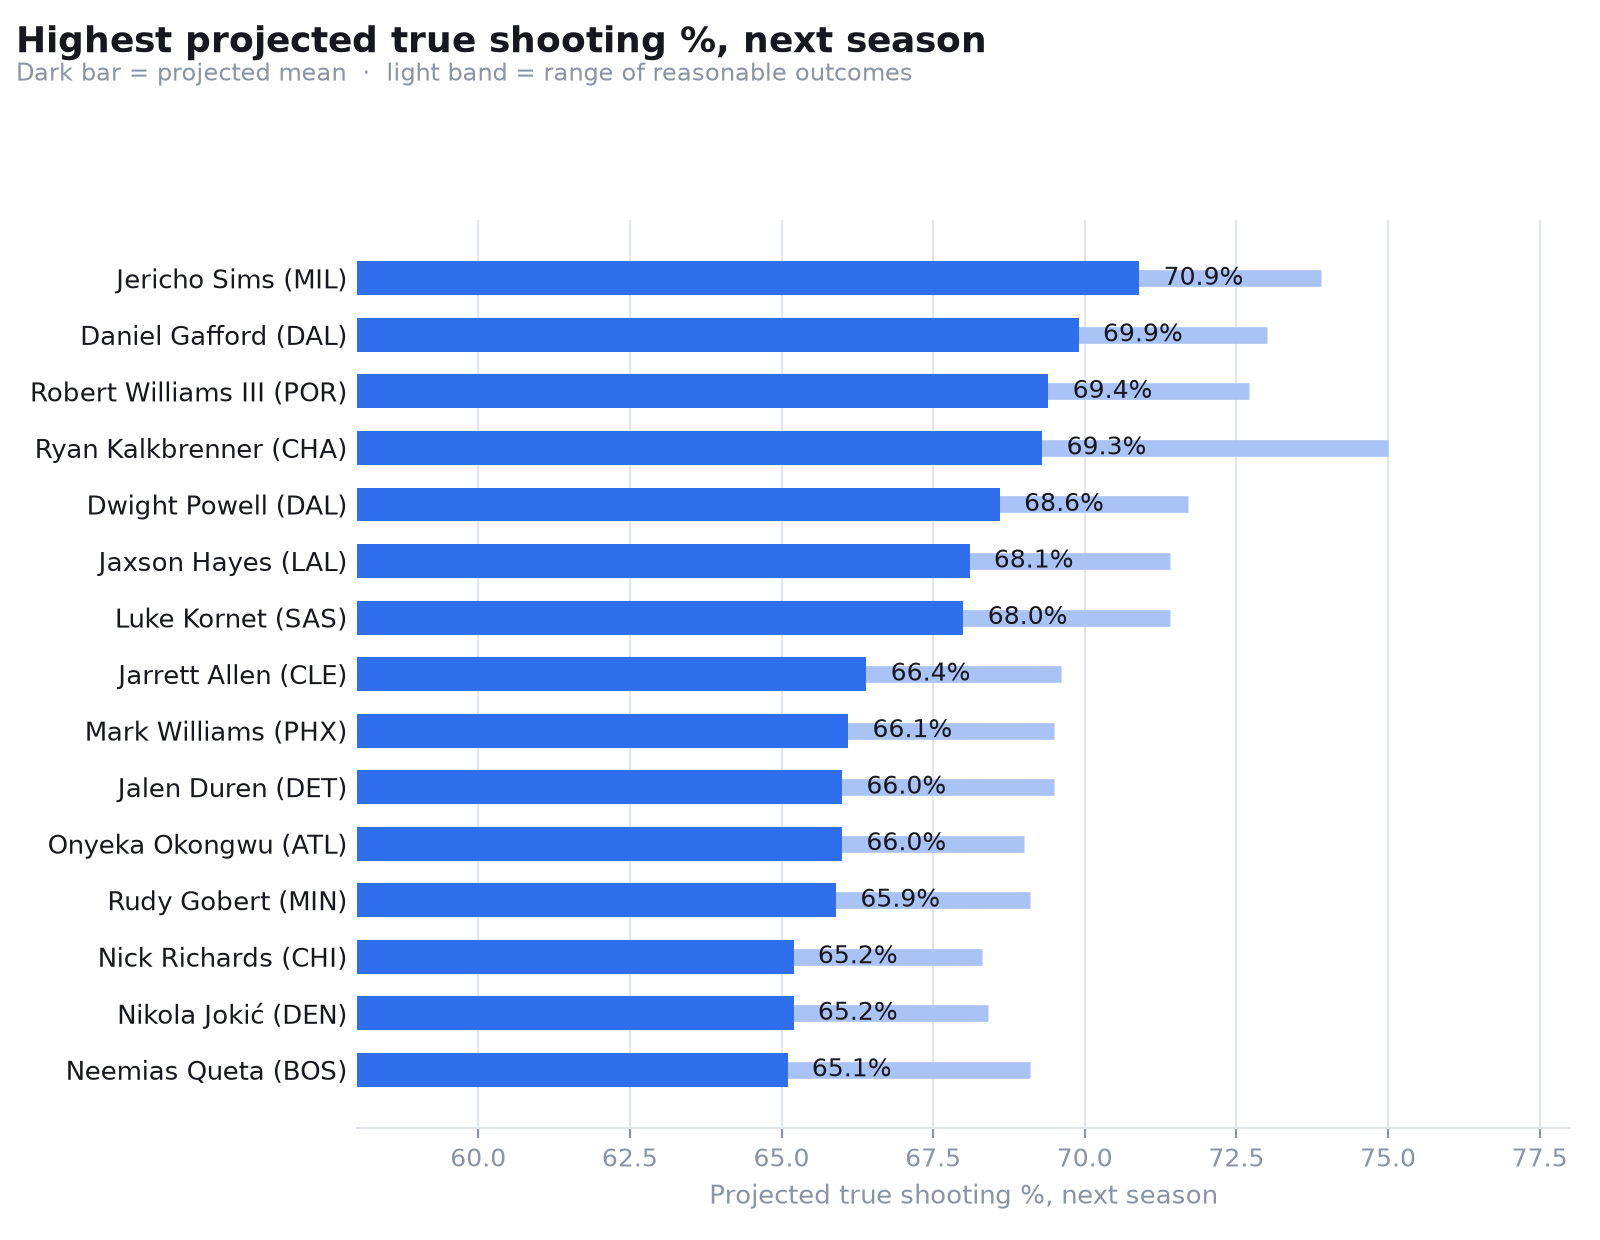

In [10]:
display(Image(filename="docs/writeup_chart.png", width=460))

In [11]:
proj = pd.read_csv("bayesian_ar_output/next_season_projections.csv")
top10 = proj.sort_values("PROJECTED_TS_PCT", ascending=False).head(10).copy()
top10["Projected TS%"] = (top10["PROJECTED_TS_PCT"] * 100).round(1).astype(str) + "%"
top10["Range"] = (
    (top10["HDI_LOW"] * 100).round(1).astype(str) + "-"
    + (top10["HDI_HIGH"] * 100).round(1).astype(str) + "%"
)
top10[["PLAYER_NAME", "TEAM", "Projected TS%", "Range"]].reset_index(drop=True)

,PLAYER_NAME,TEAM,Projected TS%,Range
0,Jericho Sims,MIL,70.9%,67.8-73.9%
1,Daniel Gafford,DAL,69.9%,66.8-73.0%
2,Robert Williams III,POR,69.4%,65.9-72.7%
3,Ryan Kalkbrenner,CHA,69.3%,63.6-75.0%
4,Dwight Powell,DAL,68.6%,65.5-71.7%
5,Jaxson Hayes,LAL,68.1%,65.0-71.4%
6,Luke Kornet,SAS,68.0%,64.5-71.4%
7,Jarrett Allen,CLE,66.4%,63.6-69.6%
8,Mark Williams,PHX,66.1%,62.7-69.5%
9,Jalen Duren,DET,66.0%,62.7-69.5%


**Why it's mostly centers.** TS% rewards a specific kind of efficiency: low-usage
bigs who mostly finish at the rim off dunks, lobs, and putbacks post the highest
numbers, because the shots they take go in at an extremely high rate, even though
they take far fewer of them than a star wing or point guard creating his own shot
against a set defense. Nikola Jokić showing up here is the exception that proves the
rule: a superstar who's also one of the most efficient scorers alive at any usage
level. None of this is a model flaw; it's just what the stat measures.

**What this doesn't know.** The model can't see a role change coming, and it can't
project a player with zero NBA track record: a true rookie who hasn't played a
qualifying season isn't in this list at all, because there's no lag to condition on.

## 5. Extending to assists, rebounds, and defense: the breakout dashboard

The same flexible-lag AR(3) architecture generalizes to three more per-season
stats: `AST_PCT` (assist rate), `REB_PCT` (rebound rate), and
`DEF_RATING` (points allowed per 100 possessions, sign-flipped so positive always
means "expected to get better"). All four are fit on a shared player-season universe
(`SEASON_MIN_EST >= 500`, a playing-time floor rather than TS%'s attempts floor).

For each stat, `DELTA = projected − current` is z-scored across all 379 projected
players, putting TS%'s ±0.05 scale, the percentage-rate stats, and `DEF_RATING`'s
~100-point scale on the same footing, and the four z-scores are averaged into a
single **breakout score**: who's expected to improve the most across shooting,
playmaking, rebounding, and defense together, not who will simply be *best*. This
ranking also powers a self-contained, sortable, searchable interactive dashboard.

In [12]:
combined = pd.read_csv("bayesian_ar_output/next_season_projections_all.csv")
top_breakout = combined.sort_values("BREAKOUT_SCORE", ascending=False).head(10).copy()
top_breakout = top_breakout[[
    "PLAYER_NAME", "TEAM", "BREAKOUT_SCORE",
    "DELTA_TS_PCT", "DELTA_AST_PCT", "DELTA_REB_PCT", "DELTA_DEF_RATING",
]].round(3)
top_breakout.columns = ["Player", "Team", "Score", "ΔTS%", "ΔAST%", "ΔREB%", "ΔDEF"]
top_breakout.reset_index(drop=True)

,Player,Team,Score,ΔTS%,ΔAST%,ΔREB%,ΔDEF
0,Jahmai Mashack,MEM,1.342,0.056,-0.016,0.003,5.801
1,Daeqwon Plowden,SAC,1.263,0.005,0.012,0.003,7.326
2,Elijah Harkless,UTA,1.157,0.053,-0.022,0.004,3.054
3,Micah Peavy,NOP,1.142,0.059,-0.009,0.003,1.928
4,Cam Thomas,MIL,1.132,0.020,0.034,0.000,5.188
5,Gary Trent Jr.,MIL,1.101,0.027,0.009,0.003,4.013
6,Tre Mann,CHA,1.029,0.055,-0.003,0.001,2.386
7,Keegan Murray,SAC,1.026,0.040,0.017,0.000,3.183
8,Terrence Shannon Jr.,MIN,0.979,-0.009,0.005,0.004,5.918
9,Aaron Nesmith,IND,0.972,0.037,0.015,0.000,3.015


Two things worth reading correctly before trusting the ranking: this measures expected
**improvement**, not expected quality: players already near the top of a stat have
little room to climb, so established stars routinely show a *negative* breakout score
(regression toward the mean, not a predicted decline). And a high score on very little
playing time is often the same reversion effect working in the other direction,
pulling a small-sample rookie season up toward the population mean, which is what a
minimum-playing-time filter is for. The full, interactive version covers all 379
projected players.

## 6. Conclusion

Across roughly 2,300 real player-seasons (2021-22 through 2025-26), the pooled
Bayesian AR(3) model recovers a believable, well-diagnosed picture of NBA shooting
efficiency: a curved age effect, meaningful season-to-season persistence, and no
separate signal left in usage rate once history and age are accounted for. The
hierarchical extension confirms that a large share of the remaining variance is
genuinely about who the player is, not just noise, but its own model-comparison
result carries a reliability warning the simpler pooled model doesn't, so it's the
pooled model's fit this project trusts by default.

Next season's projected shooting leaderboard is dominated by low-usage, high-
efficiency bigs, exactly what TS% is built to reward, and every number ships with an
honest range rather than a single confident guess. The same architecture extends
cleanly to assists, rebounds, and defense, producing a breakout score that ranks
projected *improvement* rather than projected quality: a modeling approach that
stays honest about its own limits throughout.